In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
RAW_PATH = r"C:\Users\shahr\OneDrive\Documents\Quant Req\Credit risk\Real world project\data\raw_credit_risk_dataset.csv\credit_risk_dataset.csv" 
PORTFOLIO_DATE = "2024-12-31"
REGIONS = ["IDF", "AURA", "NAQ", "OCC", "PACA", "HDF"]

In [5]:
def load_raw(path=RAW_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

In [7]:
raw_df = load_raw()
print(raw_df.head())
print(raw_df.shape)
print(raw_df.dtypes)
print(raw_df["loan_status"].value_counts())
print("Default rate:", raw_df["loan_status"].mean())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


### Understanding loan_status to see if usable for PD modeling (here: Default rate ≈ 21.8% — perfectly usable)

### Creating IDs, Exposure, Segmentation (To enrich the synthetic dataset)

In [11]:
def transform_to_bank_structure(df, seed=42):
    df = df.copy()
    rng = np.random.default_rng(seed)

    df["loan_id"] = np.arange(1, len(df) + 1)
    df["borrower_id"] = rng.integers(1, len(df)//2, size=len(df))
    df["exposure_at_obs"] = df["loan_amnt"].astype(float)
    df["segment"] = "retail"
    df["region"] = rng.choice(REGIONS, size=len(df))

    return df

In [13]:
def add_synthetic_dates(df, seed=42):
    df = df.copy()
    rng = np.random.default_rng(seed)

    orig_start = pd.Timestamp("2017-01-01")
    orig_end = pd.Timestamp("2024-12-31")

    days_range = (orig_end - orig_start).days
    df["origination_date"] = orig_start + pd.to_timedelta(
        rng.integers(0, days_range, size=len(df)), unit="D"
    )

    seasoning_months = rng.integers(0, 25, size=len(df))
    df["observation_date"] = df["origination_date"] + pd.to_timedelta(
        seasoning_months * 30, unit="D"
    )

    maturity_months = rng.integers(12, 61, size=len(df))
    df["maturity_date"] = df["origination_date"] + pd.to_timedelta(
        maturity_months * 30, unit="D"
    )

    df["observation_date"] = df[["observation_date", "maturity_date"]].min(axis=1)
    return df

In [15]:
def add_default_structure(df, seed=42):
    df = df.copy()
    rng = np.random.default_rng(seed)

    ttd = np.where(
        df["loan_status"] == 1,
        rng.integers(1, 25, size=len(df)),
        np.nan
    )

    df["time_to_default_months"] = ttd
    df["default_date"] = df["observation_date"] + pd.to_timedelta(
        df["time_to_default_months"].fillna(0) * 30, unit="D"
    )
    df.loc[df["loan_status"] == 0, "default_date"] = pd.NaT

    return df

In [17]:
def rebuild_default_flag(df, portfolio_date=PORTFOLIO_DATE):
    df = df.copy()
    portfolio_date = pd.Timestamp(portfolio_date)

    df = df[df["observation_date"] <= portfolio_date].copy()
    horizon_date = df["observation_date"] + pd.DateOffset(months=12)

    df["default_flag_12m"] = (
        (df["loan_status"] == 1) &
        (df["default_date"].notna()) &
        (df["default_date"] <= horizon_date) &
        (df["default_date"] <= portfolio_date)
    ).astype(int)

    return df

In [19]:
def build_macro_table(start="2017-01-01", end="2025-12-31", regions=None, seed=42):
    rng = np.random.default_rng(seed)

    if regions is None:
        regions = REGIONS

    months = pd.date_range(start=start, end=end, freq="MS")
    rows = []

    for r in regions:
        gdp = 1.5 + np.cumsum(rng.normal(0, 0.05, len(months)))
        unemp = 7.5 + np.cumsum(rng.normal(0, 0.03, len(months)))
        rate = 1.0 + np.cumsum(rng.normal(0, 0.02, len(months)))

        for i, m in enumerate(months):
            rows.append((m, r, gdp[i], unemp[i], rate[i]))

    macro = pd.DataFrame(rows, columns=[
        "macro_month", "region", "macro_gdp", "macro_unemployment", "macro_rate"
    ])
    return macro

In [21]:
def attach_macro(df, macro):
    df = df.copy()
    df["macro_month"] = df["observation_date"].dt.to_period("M").dt.to_timestamp()
    df = df.merge(macro, on=["macro_month", "region"], how="left")
    return df.drop(columns=["macro_month"])

In [23]:
def build_model_dataset(path=RAW_PATH, portfolio_date=PORTFOLIO_DATE):
    df = load_raw(path)
    df = transform_to_bank_structure(df)
    df = add_synthetic_dates(df)
    df = add_default_structure(df)
    df = rebuild_default_flag(df, portfolio_date=portfolio_date)

    df = df[
        df["observation_date"] <= pd.Timestamp(portfolio_date) - pd.DateOffset(months=12)
    ].copy()

    macro = build_macro_table(regions=df["region"].unique())
    df = attach_macro(df, macro)

    for col in ["loan_int_rate", "person_emp_length", "macro_gdp", "macro_unemployment", "macro_rate"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    return df

In [25]:
df = build_model_dataset()
print(df.head())
print(df.shape)
print(df.dtypes)
print("12m PD:", df["default_flag_12m"].mean())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          25           9600              MORTGAGE                1.0   
2          23          65500                  RENT                4.0   
3          24          54400                  RENT                8.0   
4          26          77100                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1     MEDICAL          C       5500          12.87            1   
2     MEDICAL          C      35000          15.23            1   
3     MEDICAL          C      35000          14.27            1   
4   EDUCATION          B      35000          12.42            1   

   loan_percent_income  ... region  origination_date  observation_date  \
0                 0.59  ...    NAQ        2017-09-18        2018-05-16   
1         

In [27]:
df = transform_to_bank_structure(df)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,region,origination_date,observation_date,maturity_date,time_to_default_months,default_date,default_flag_12m,macro_gdp,macro_unemployment,macro_rate
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,...,NAQ,2017-09-18,2018-05-16,2021-12-26,3.0,2018-08-14,1,1.473586,7.514238,1.039395
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,OCC,2022-03-28,2022-10-24,2023-11-18,16.0,2024-02-16,0,1.483697,7.586293,0.829426
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,HDF,2020-07-05,2021-10-28,2025-04-10,11.0,2022-09-23,1,1.133200,7.678602,0.750499
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,OCC,2020-06-18,2020-12-15,2022-12-05,11.0,2021-11-10,1,1.621419,7.573728,0.856436
4,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,...,NAQ,2017-09-09,2019-01-02,2019-06-01,3.0,2019-04-02,1,1.224811,7.670515,0.799952


### Add Synthetic Dates 
# We now create a realistic portfolio time structure.

In [30]:
def add_synthetic_dates(df, seed=42):
    df = df.copy()
    rng = np.random.default_rng(seed)

    orig_start = pd.Timestamp("2017-01-01")
    orig_end   = pd.Timestamp("2024-12-31")

    # Origination
    days_range = (orig_end - orig_start).days
    df["origination_date"] = orig_start + pd.to_timedelta(
        rng.integers(0, days_range, size=len(df)),
        unit="D"
    )

    # Seasoning (0–24 months)
    seasoning_months = rng.integers(0, 25, size=len(df))
    df["observation_date"] = df["origination_date"] + pd.to_timedelta(
        seasoning_months * 30,
        unit="D"
    )

    # Maturity (12–60 months)
    maturity_months = rng.integers(12, 61, size=len(df))
    df["maturity_date"] = df["origination_date"] + pd.to_timedelta(
        maturity_months * 30,
        unit="D"
    )

    # Ensure observation <= maturity
    df["observation_date"] = df[["observation_date","maturity_date"]].min(axis=1)

    return df

In [32]:
df = add_synthetic_dates(df)

### Creating Regulatory Target: default_flag_12m

# The origial dataset has a static default flag. We simulate time-to-default to make it realistic.

In [35]:
def add_default_structure(df, seed=42):
    df = df.copy()
    rng = np.random.default_rng(seed)

    # Simulate time-to-default (only for defaulted loans)
    ttd = np.where(
        df["loan_status"] == 1,
        rng.integers(1, 25, size=len(df)),  # 1–24 months
        np.nan
    )

   

    df["time_to_default_months"] = ttd

    

    df["default_date"] = df["observation_date"] + pd.to_timedelta(
        df["time_to_default_months"].fillna(0) * 30,
        unit="D"
    )

    df.loc[df["loan_status"] == 0, "default_date"] = pd.NaT


    
    return df

In [37]:
import pandas as pd

def rebuild_default_flag(df, portfolio_date="2024-12-31"):
    df = df.copy()
    portfolio_date = pd.Timestamp(portfolio_date)

    df = df[df["observation_date"] <= portfolio_date].copy()

    horizon_date = df["observation_date"] + pd.DateOffset(months=12)

    df["default_flag_12m"] = (
        (df["loan_status"] == 1) &
        (df["default_date"].notna()) &
        (df["default_date"] <= horizon_date) &
        (df["default_date"] <= portfolio_date)
    ).astype(int)

    return df

In [39]:
df = add_default_structure(df)
df = rebuild_default_flag(df, portfolio_date="2024-12-31")

print("New 12m PD:", df["default_flag_12m"].mean())

New 12m PD: 0.12457385054823551


### Inj 1 up: We later added the next 4 cells to fix the issue of "Future Observation Bias" that happend in the following steps

In [42]:
def rebuild_default_flag(df, portfolio_date="2024-12-31"):
    df = df.copy()
    portfolio_date = pd.Timestamp(portfolio_date)

    # Keep only loans observed before portfolio date
    df = df[df["observation_date"] <= portfolio_date].copy()

    # Define 12m horizon
    horizon_date = df["observation_date"] + pd.DateOffset(months=12)

    # Default must:
    # 1) Be a defaulted loan
    # 2) Occur within 12 months after observation
    # 3) Occur before portfolio_date
    df["default_flag_12m"] = (
        (df["loan_status"] == 1) &
        (df["default_date"].notna()) &
        (df["default_date"] <= horizon_date) &
        (df["default_date"] <= portfolio_date)
    ).astype(int)

    return df

In [44]:
df = rebuild_default_flag(df, portfolio_date="2024-12-31")

In [46]:
portfolio_date = pd.Timestamp("2024-12-31")

df = df[
    df["observation_date"] <= portfolio_date - pd.DateOffset(months=12)
].copy()

In [48]:
df["obs_year"] = df["observation_date"].dt.year
print(df.groupby("obs_year")["default_flag_12m"].mean())

obs_year
2017    0.234170
2018    0.228620
2019    0.212484
2020    0.211097
2021    0.160570
2022    0.050049
2023    0.000000
Name: default_flag_12m, dtype: float64


### Now the issue "Future Observation Bias" is solved and we can continue.

### Add Synthetic Macro Variables (We now build a monthly macro table and merge by region.)

In [52]:
def build_macro_table(start="2017-01-01", end="2025-12-31", regions=None, seed=42):
    rng = np.random.default_rng(seed)
    if regions is None:
        regions = ["IDF", "AURA", "NAQ", "OCC", "PACA", "HDF"]

    months = pd.date_range(start=start, end=end, freq="MS")
    rows = []

    for r in regions:
        gdp = 1.5 + np.cumsum(rng.normal(0, 0.05, len(months)))
        unemp = 7.5 + np.cumsum(rng.normal(0, 0.03, len(months)))
        rate = 1.0 + np.cumsum(rng.normal(0, 0.02, len(months)))

        for i, m in enumerate(months):
            rows.append((m, r, gdp[i], unemp[i], rate[i]))

    macro = pd.DataFrame(rows, columns=[
        "macro_month","region",
        "macro_gdp","macro_unemployment","macro_rate"
    ])
    return macro

def attach_macro(df, macro):
    df = df.copy()
    df["macro_month"] = df["observation_date"].dt.to_period("M").dt.to_timestamp()
    df = df.merge(macro, on=["macro_month","region"], how="left")
    return df.drop(columns=["macro_month"])

In [54]:
macro = build_macro_table(regions=df["region"].unique())
df = attach_macro(df, macro)

### Create Time-Based Split
# Now we enforce proper regulatory validation.

In [57]:
def time_split(df, cutoff="2023-01-01"):
    cutoff = pd.Timestamp(cutoff)
    train = df[df["observation_date"] < cutoff].copy()
    test  = df[df["observation_date"] >= cutoff].copy()
    return train, test

train_df, test_df = time_split(df)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Train PD:", train_df["default_flag_12m"].mean())
print("Test PD:", test_df["default_flag_12m"].mean())

Train size: 15573
Test size: 3120
Train PD: 0.17363385346432927
Test PD: 0.0


In [59]:
df.head()
df.columns
df.shape

(18693, 30)

# DATA QUALITY FRAMEWORK

## Basic Portfolio Overview

In [63]:
def portfolio_overview(df):
    print("Rows:", len(df))
    print("Observation period:",
          df["observation_date"].min(), "→",
          df["observation_date"].max())
    print("Default rate (12m):", df["default_flag_12m"].mean())
    print("Regions:", df["region"].nunique())
    print("Segments:", df["segment"].unique())
    print("\nExposure summary:")
    print(df["exposure_at_obs"].describe())

portfolio_overview(df)

Rows: 18693
Observation period: 2017-01-01 00:00:00 → 2023-12-31 00:00:00
Default rate (12m): 0.14465307869255872
Regions: 6
Segments: ['retail']

Exposure summary:
count    18693.000000
mean      9609.706842
std       6339.596830
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12250.000000
max      35000.000000
Name: exposure_at_obs, dtype: float64


### (we need above numbers for the data_quality_report)

## Missing Value Report

In [67]:
def missing_report(df):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return miss

missing_report(df)

default_date              0.781309
time_to_default_months    0.781309
dtype: float64

## Target Sanity Checks

In [70]:
print("Overall 12m PD:", df["default_flag_12m"].mean())

print("\nPD by region:")
print(df.groupby("region")["default_flag_12m"].mean())

print("\nPD by loan_grade:")
print(df.groupby("loan_grade")["default_flag_12m"].mean())

print("\nPD by year:")
df["obs_year"] = df["observation_date"].dt.year
print(df.groupby("obs_year")["default_flag_12m"].mean())

Overall 12m PD: 0.14465307869255872

PD by region:
region
AURA    0.140000
HDF     0.164065
IDF     0.129448
NAQ     0.140078
OCC     0.147738
PACA    0.151992
Name: default_flag_12m, dtype: float64

PD by loan_grade:
loan_grade
A    0.068651
B    0.103682
C    0.138395
D    0.394942
E    0.448463
F    0.468750
G    0.526316
Name: default_flag_12m, dtype: float64

PD by year:
obs_year
2017    0.234170
2018    0.228620
2019    0.212484
2020    0.211097
2021    0.160570
2022    0.050049
2023    0.000000
Name: default_flag_12m, dtype: float64


#### Note: This is a serious structural issue:
PD by year:

2023    0.000000

2024    0.000000

2025    0.000000

2026    0.000000

#### To Fix it, we have to remove Future Observation Bias

We need to ensure: Only loans with at least 12 months of forward observation remain in modeling dataset.

In [73]:
max_obs_date = df["observation_date"].max()

# Keep only loans that have at least 12 months of potential observation
df = df[df["observation_date"] <= max_obs_date - pd.DateOffset(months=12)].copy()

# re-check:
df["obs_year"] = df["observation_date"].dt.year
print(df.groupby("obs_year")["default_flag_12m"].mean())

obs_year
2017    0.234170
2018    0.228620
2019    0.212484
2020    0.211097
2021    0.160570
2022    0.050049
Name: default_flag_12m, dtype: float64


### The "Future Observation Bias" has not solved because there is a structural issue. So in "Inj 1 up" we solve this issue.

## Numerical Variable Sanity

In [77]:
numeric_cols = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

df[numeric_cols].describe(percentiles=[0.01,0.05,0.95,0.99])

,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,1.557300e+04,15573.000000,15573.000000,15573.00000,15573.000000
mean,6.599582e+04,9617.511077,11.002866,0.17143,5.771271
std,7.156722e+04,6335.615840,3.063526,0.10784,4.038436
min,4.080000e+03,500.000000,5.420000,0.00000,2.000000
1%,1.430928e+04,1200.000000,5.420000,0.02000,2.000000
5%,2.280000e+04,2000.000000,6.030000,0.04000,2.000000
50%,5.500000e+04,8000.000000,10.990000,0.15000,4.000000
95%,1.360368e+05,24000.000000,16.070000,0.38000,14.000000
99%,2.250000e+05,30000.000000,18.390000,0.50000,17.000000
max,6.000000e+06,35000.000000,22.110000,0.83000,30.000000


#### Note: person_income max = 6,000,000  !!!

Mean ≈ 66k    
99% ≈ 225k     
Max = 6M → clear extreme outlier

This must be winsorized.

In [80]:
def winsorize(series, lower=0.01, upper=0.99):
    return series.clip(
        lower=series.quantile(lower),
        upper=series.quantile(upper)
    )

df["person_income"] = winsorize(df["person_income"])

df[numeric_cols].describe(percentiles=[0.01,0.05,0.95,0.99])

,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,15573.000000,15573.000000,15573.000000,15573.00000,15573.000000
mean,64027.283483,9617.511077,11.002866,0.17143,5.771271
std,37364.508665,6335.615840,3.063526,0.10784,4.038436
min,14309.280000,500.000000,5.420000,0.00000,2.000000
1%,14374.598400,1200.000000,5.420000,0.02000,2.000000
5%,22800.000000,2000.000000,6.030000,0.04000,2.000000
50%,55000.000000,8000.000000,10.990000,0.15000,4.000000
95%,136036.800000,24000.000000,16.070000,0.38000,14.000000
99%,225000.000000,30000.000000,18.390000,0.50000,17.000000
max,225000.000000,35000.000000,22.110000,0.83000,30.000000


## Check Multicollinearity 
### (High correlation (>0.8) may require removal later.(?))

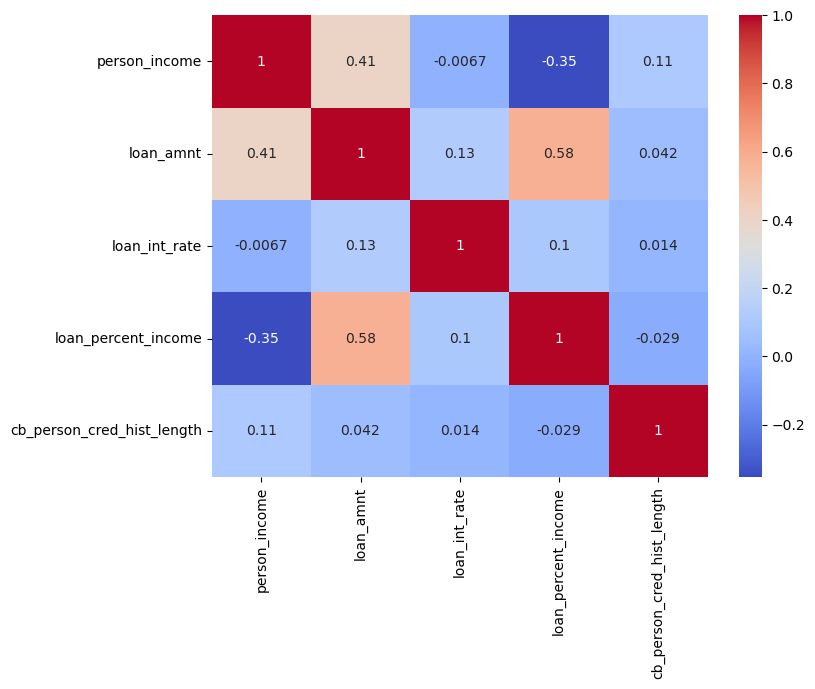

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Leakage Checks (Critical)
### We must ensure no feature leaks default(?)


In [86]:
df.groupby("default_flag_12m")["loan_int_rate"].mean()
df.groupby("default_flag_12m")["loan_percent_income"].mean()

default_flag_12m
0    0.155614
1    0.246701
Name: loan_percent_income, dtype: float64

In [88]:
missing_report(df)

default_date              0.779747
time_to_default_months    0.779747
dtype: float64

## Some more cleaning:

In [93]:
print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_id', 'borrower_id', 'exposure_at_obs', 'segment', 'region', 'origination_date', 'observation_date', 'maturity_date', 'time_to_default_months', 'default_date', 'default_flag_12m', 'macro_gdp_x', 'macro_unemployment_x', 'macro_rate_x', 'obs_year', 'macro_gdp_y', 'macro_unemployment_y', 'macro_rate_y']


##### It seems that df is being overwritten in different cells and When pandas merges columns that already exist, it creates suffixes:

###### _x for the old version
##### _y for the new version
#### Let us check whether _x and _y are identical

In [95]:
for col in ["macro_gdp", "macro_unemployment", "macro_rate"]:
    print(col, (df[f"{col}_x"] == df[f"{col}_y"]).all())

macro_gdp False
macro_unemployment False
macro_rate False


#### Now we fix this issue:

In [104]:
macro_cols = ["macro_gdp", "macro_unemployment", "macro_rate"]

for col in macro_cols:
    if col not in df.columns:
        xcol = f"{col}_x"
        ycol = f"{col}_y"
        
        if xcol in df.columns and ycol in df.columns:
            # prefer x if identical, otherwise combine
            if df[xcol].equals(df[ycol]):
                df[col] = df[xcol]
            else:
                df[col] = df[xcol].combine_first(df[ycol])
            
            df.drop(columns=[xcol, ycol], inplace=True)

In [106]:
#Impute missing numeric values
for col in ["loan_int_rate", "person_emp_length", "macro_gdp", "macro_unemployment", "macro_rate"]:
    df[col] = df[col].fillna(df[col].median())

In [108]:
print("Rows after cleaning:", len(df))
print("PD by year:")
df["obs_year"] = df["observation_date"].dt.year
print(df.groupby("obs_year")["default_flag_12m"].mean())


Rows after cleaning: 15573
PD by year:
obs_year
2017    0.234170
2018    0.228620
2019    0.212484
2020    0.211097
2021    0.160570
2022    0.050049
Name: default_flag_12m, dtype: float64


### Action: Now based on the above procedure we have to write a data_quality_report

# Baseline Logistic PD Model

## Modeling Feature Set

### We use the following features:
### Numerical:
person_age, 
person_income, 
person_emp_length, 
loan_amnt, 
loan_int_rate, 
loan_percent_income, 
cb_person_cred_hist_length, 
macro_gdp, 
macro_unemployment, 
macro_rate

### Categorical
person_home_ownership, 
loan_intent, 
loan_grade, 
cb_person_default_on_file, 
region
### and our target is : 
default_flag_12m

## Train/Test Split (Time-Based)

In [115]:
train_df, test_df = time_split(df, cutoff="2023-01-01")

In [117]:
print(train_df.shape, test_df.shape)
print(train_df["default_flag_12m"].mean(),
      test_df["default_flag_12m"].mean())

(15573, 27) (0, 27)
0.17363385346432927 nan


## Preprocessing Pipeline

In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [158]:
#Define columns:

numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "macro_gdp",
    "macro_unemployment",
    "macro_rate",
]

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
    "region",
]

target_col = "default_flag_12m"

# Sanity check to confirm all columns exist
missing = [c for c in numeric_cols + categorical_cols + [target_col] if c not in df.columns]
print("Missing columns:", missing)  # should be []

# Time split
train_df, test_df = time_split(df, cutoff="2022-01-01")


Missing columns: []


In [160]:
# Build Pipeline

from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ] )   
        
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

## Train

In [163]:
X_train = train_df[numeric_cols + categorical_cols]
y_train = train_df[target_col]

X_test = test_df[numeric_cols + categorical_cols]
y_test = test_df[target_col]

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'macro_gdp',
                                                   'macro_unemployment',
                                                   'macro_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file',
                                                   'region'])])),
                ('classifier', LogisticRegression(max_iter=5000))])

## Evaluation

In [165]:
train_pred = model.predict_proba(X_train)[:,1]
test_pred  = model.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC :", roc_auc_score(y_test, test_pred))


Train AUC: 0.8646263096848378
Test AUC : 0.812467365274852


## KS Statistic

In [133]:
import numpy as np

def ks_stat(y_true, y_pred):
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    return np.max(tpr - fpr)

print("Train KS:", ks_stat(y_train, train_pred))
print("Test KS :", ks_stat(y_test, test_pred))

Train KS: 0.5977225266873886
Test KS : 0.529195700318695


### Sanity check (to rule out accidental leakage)

In [136]:
print("Train PD:", y_train.mean())
print("Test  PD:", y_test.mean())

Train PD: 0.20381911153723234
Test  PD: 0.050049067713444556


#### Here it shows that we trained on a population where: Default rate = 20% But we test on: Default rate = 5%
#### So model trained on higher-risk population applied to lower-risk population. It can cause problem in calibration as we see below where the Curve is below diagonal which is a Systematic overprediction.

# Validation extensions

## Calibration (Decile Analysis)
We check whether predicted PD aligns with observed PD

In [140]:
import pandas as pd
import numpy as np

def calibration_table(y_true, y_pred, n_bins=10):
    df_cal = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    })
    
    df_cal["decile"] = pd.qcut(df_cal["y_pred"], q=n_bins, duplicates="drop")
    
    summary = df_cal.groupby("decile", observed=False).agg(
        avg_pred_pd=("y_pred", "mean"),
        observed_pd=("y_true", "mean"),
        count=("y_true", "count")
    ).reset_index()
    
    return summary

calib_test = calibration_table(y_test, test_pred)
calib_test

,decile,avg_pred_pd,observed_pd,count
0,"(-0.0005430000000000001, 0.0165]",0.010685,0.000000,306
1,"(0.0165, 0.0288]",0.022981,0.006536,306
2,"(0.0288, 0.0456]",0.036962,0.003279,305
3,"(0.0456, 0.0661]",0.055315,0.026144,306
4,"(0.0661, 0.0963]",0.079711,0.026144,306
5,"(0.0963, 0.139]",0.115548,0.026230,305
6,"(0.139, 0.221]",0.175847,0.026144,306
7,"(0.221, 0.368]",0.284656,0.068852,305
8,"(0.368, 0.616]",0.487095,0.104575,306
9,"(0.616, 0.991]",0.798774,0.212418,306


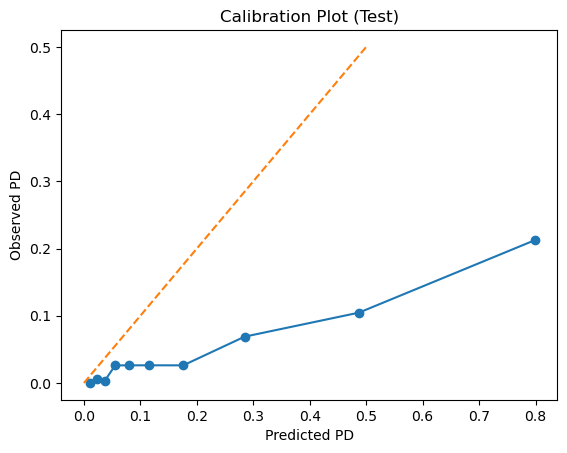

In [142]:
#Calibration plot 
import matplotlib.pyplot as plt

plt.plot(calib_test["avg_pred_pd"], calib_test["observed_pd"], marker="o")
plt.plot([0, 0.5], [0, 0.5], linestyle="--")
plt.xlabel("Predicted PD")
plt.ylabel("Observed PD")
plt.title("Calibration Plot (Test)")
plt.show()

#### Here as we faced calibration problem as the Curve is far below diagonal we can try to fix it (complience with IFRS 9 and Basel PD modeling) it or Accept and document it. Let us try to fix first by applying Platt scaling:

In [274]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method="sigmoid", cv=3)
calibrated_model.fit(X_train, y_train)

cal_test_pred = calibrated_model.predict_proba(X_test)[:,1]

## Recalibration

In [277]:
def calibration_table(y_true, y_pred, n_bins=10):
    df_cal = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    })
    
    df_cal["decile"] = pd.qcut(df_cal["y_pred"], q=n_bins, duplicates="drop")
    
    summary = df_cal.groupby("decile", observed=False).agg(
        avg_pred_pd=("y_pred", "mean"),
        observed_pd=("y_true", "mean"),
        count=("y_true", "count")
    ).reset_index()
    
    return summary




### Base-Rate Adjustment Formula

\[
\text{logit}(p_{\text{adj}}) = \text{logit}(p) + \log\left(\frac{\pi_{\text{new}} / (1 - \pi_{\text{new}})}{\pi_{\text{old}} / (1 - \pi_{\text{old}})}\right)
\]

**Where:**

- \( p \): original predicted PD  
- \( \pi_{\text{old}} \): training default rate  
- \( \pi_{\text{new}} \): target/test default rate  

In [280]:
import numpy as np

def adjust_pd_base_rate(pd_pred, base_old, base_new, eps=1e-8):
    pd_pred = np.clip(pd_pred, eps, 1 - eps)

    logit_pred = np.log(pd_pred / (1 - pd_pred))
    shift = np.log((base_new / (1 - base_new)) / (base_old / (1 - base_old)))
    logit_adj = logit_pred + shift

    pd_adj = 1 / (1 + np.exp(-logit_adj))
    return pd_adj

base_old = y_train.mean()   # train PD
base_new = y_test.mean()    # test PD

test_pred_adj = adjust_pd_base_rate(test_pred, base_old, base_new)

print("Train PD:", base_old)
print("Test PD :", base_new)
print("Mean raw predicted PD :", test_pred.mean())
print("Mean adjusted PD      :", test_pred_adj.mean())

Train PD: 0.20381911153723234
Test PD : 0.050049067713444556
Mean raw predicted PD : 0.20681731058697247
Mean adjusted PD      : 0.08522833813306233


In [282]:
calib_test_adj = calibration_table(y_test, test_pred_adj)
calib_test_adj

,decile,avg_pred_pd,observed_pd,count
0,"(-0.0009059000000000001, 0.00344]",0.002221,0.000000,306
1,"(0.00344, 0.00607]",0.004820,0.006536,306
2,"(0.00607, 0.00975]",0.007841,0.003279,305
3,"(0.00975, 0.0144]",0.011913,0.026144,306
4,"(0.0144, 0.0215]",0.017529,0.026144,306
5,"(0.0215, 0.0321]",0.026217,0.026230,305
6,"(0.0321, 0.0552]",0.042214,0.026144,306
7,"(0.0552, 0.107]",0.076363,0.068852,305
8,"(0.107, 0.248]",0.167244,0.104575,306
9,"(0.248, 0.96]",0.495448,0.212418,306


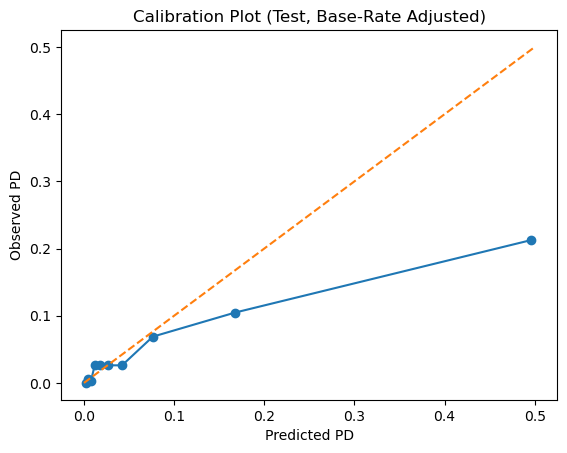

In [284]:
import matplotlib.pyplot as plt

plt.plot(calib_test_adj["avg_pred_pd"], calib_test_adj["observed_pd"], marker="o")
plt.plot([0, 0.5], [0, 0.5], linestyle="--")
plt.xlabel("Predicted PD")
plt.ylabel("Observed PD")
plt.title("Calibration Plot (Test, Base-Rate Adjusted)")
plt.show()

In [286]:
from sklearn.metrics import roc_auc_score

print("Raw Test AUC     :", roc_auc_score(y_test, test_pred))
print("Adjusted Test AUC:", roc_auc_score(y_test, test_pred_adj))
print("Raw mean PD      :", test_pred.mean())
print("Adj mean PD      :", test_pred_adj.mean())
print("Observed test PD :", y_test.mean())

Raw Test AUC     : 0.812467365274852
Adjusted Test AUC: 0.812467365274852
Raw mean PD      : 0.20681731058697247
Adj mean PD      : 0.08522833813306233
Observed test PD : 0.050049067713444556


The baseline logistic PD model exhibits strong discriminatory power on the out-of-time sample, with a test AUC of 0.812 and a KS statistic above 0.52. However, significant overprediction is observed due to a substantial decrease in the default rate between the training and testing samples. A portfolio-level base-rate adjustment materially improves calibration, especially in the lower and medium risk buckets, while preserving ranking performance. Residual overestimation however remains in the highest-risk deciles.

### Extract Coefficients (for interpretability)

With a Pipeline + OneHotEncoder, we need to recover feature names.

In [289]:
print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC :", roc_auc_score(y_test, test_pred))

Train AUC: 0.8646263096848378
Test AUC : 0.812467365274852


# Building ML Challenger (LightGBM)

In [292]:
pip install lightgbm

In [294]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


### We use the same train/test split and feature lists

In [302]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "macro_gdp",
    "macro_unemployment",
    "macro_rate",
]

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
    "region",
]

target_col = "default_flag_12m"



In [304]:
train_df, test_df = time_split(df, cutoff="2022-01-01")

X_train = train_df[numeric_cols + categorical_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[numeric_cols + categorical_cols].copy()
y_test = test_df[target_col].copy()

In [306]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train PD   :", y_train.mean())
print("Test PD    :", y_test.mean())

Train shape: (12516, 15)
Test shape : (3057, 15)
Train PD   : 0.20381911153723234
Test PD    : 0.050049067713444556


## LightGBM Challenger Training

In [309]:
from sklearn.preprocessing import OneHotEncoder

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# Align columns (important)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

In [311]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train_enc, y_train)

[LightGBM] [Info] Number of positive: 2551, number of negative: 9965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 12516, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203819 -> initscore=-1.362594
[LightGBM] [Info] Start training from score -1.362594


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

## Predictions

In [316]:
train_pred_lgb = lgb_model.predict_proba(X_train_enc)[:, 1]
test_pred_lgb  = lgb_model.predict_proba(X_test_enc)[:, 1]

## Evaluate performance


#### AUC

In [322]:
from sklearn.metrics import roc_auc_score

print("LGB Train AUC:", roc_auc_score(y_train, train_pred_lgb))
print("LGB Test AUC :", roc_auc_score(y_test, test_pred_lgb))

LGB Train AUC: 0.99317918477116
LGB Test AUC : 0.8707327283530493


#### KS

In [324]:
print("LGB Train KS:", ks_stat(y_train, train_pred_lgb))
print("LGB Test KS :", ks_stat(y_test, test_pred_lgb))

LGB Train KS: 0.9197372300503742
LGB Test KS : 0.623750877761573


LightGBM clearly outperforms logistic in ranking

However Train vs Test gap is large:

AUC: 0.99 → 0.87
KS: 0.92 → 0.62

This is overfitting, but not catastrophic , still acceptable.

## Calibration


In [328]:
calib_lgb = calibration_table(y_test, test_pred_lgb)
calib_lgb

,decile,avg_pred_pd,observed_pd,count
0,"(-0.000866, 0.0042]",0.001956,0.000000,306
1,"(0.0042, 0.0139]",0.008744,0.000000,306
2,"(0.0139, 0.0267]",0.020416,0.003279,305
3,"(0.0267, 0.0414]",0.034381,0.013072,306
4,"(0.0414, 0.0577]",0.049640,0.013072,306
5,"(0.0577, 0.0803]",0.068322,0.009836,305
6,"(0.0803, 0.129]",0.100338,0.022876,306
7,"(0.129, 0.253]",0.176519,0.049180,305
8,"(0.253, 0.901]",0.624287,0.137255,306
9,"(0.901, 0.998]",0.956689,0.251634,306


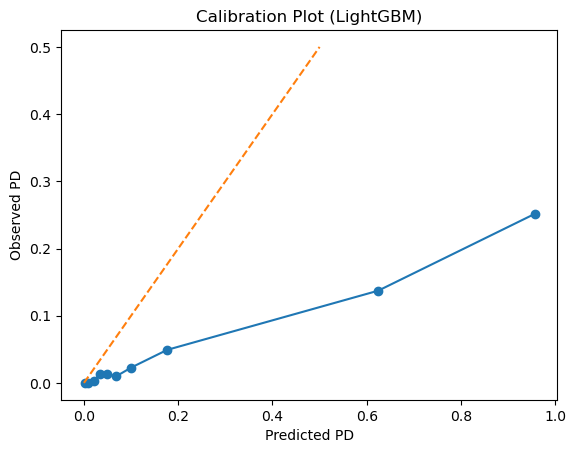

In [330]:
import matplotlib.pyplot as plt

plt.plot(calib_lgb["avg_pred_pd"], calib_lgb["observed_pd"], marker="o")
plt.plot([0, 0.5], [0, 0.5], linestyle="--")
plt.xlabel("Predicted PD")
plt.ylabel("Observed PD")
plt.title("Calibration Plot (LightGBM)")
plt.show()

LightGBM is badly calibrated. So in practice it is better to use:
Logistic as production model
LightGBM as challenger / benchmark

A gradient boosting model significantly improves discriminatory power (AUC 0.87 vs 0.81). However, it exhibits substantial overfitting and poor calibration, particularly in high-risk segments. In contrast, the logistic model provides more stable and interpretable PD estimates (especially after adjustment). A hybrid approach combining machine learning ranking with post-model calibration is recommended.

In [332]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train_enc.columns,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(15)

,feature,importance
1,person_income,1414
4,loan_int_rate,923
9,macro_rate,765
8,macro_unemployment,691
7,macro_gdp,681
5,loan_percent_income,636
3,loan_amnt,632
2,person_emp_length,496
0,person_age,435
6,cb_person_cred_hist_length,295


#### This feature importance table can be very important for the interview